# 08 - V2.1 Multi-Horizon Price-Drop Modelling

This notebook develops the V2.1 price-drop prediction model for the Smart Buy Window Predictor.

The goal is to train and evaluate separate models for three prediction horizons:

- 7-day meaningful price drop
- 14-day meaningful price drop
- 30-day meaningful price drop

A positive label means that the selected modelling price drops by at least 5% and at least $5 within the future horizon window.

This notebook is treated as a candidate replacement for the original MVP model. Therefore, it includes label validation, baseline comparison, threshold selection, held-out test evaluation, and shopper-style backtesting before saving final artifacts.

In [45]:
# Cell 2 - Imports and Configuration

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

CLEAN_DATA_PATH = PROJECT_ROOT / "data/processed/clean_data_v2.csv"
FEATURES_V2_PATH = PROJECT_ROOT / "data/processed/features_v2.csv"
OUTPUT_DIR = PROJECT_ROOT / "models/v2_1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZONS = [7, 14, 30]

MIN_DROP_PCT = 0.05
MIN_DROP_ABSOLUTE = 5.0

RANDOM_STATE = 42

print("Project root:", PROJECT_ROOT)
print("Clean data exists:", CLEAN_DATA_PATH.exists())
print("Existing V2 features exists:", FEATURES_V2_PATH.exists())

Project root: /Users/hibaswaidan/Desktop/smart-buy-window-predictor
Clean data exists: True
Existing V2 features exists: True


## Data Loading and Sanity Checks

The V2.1 notebook starts from `clean_data_v2.csv`, because the new 7-day and 30-day targets need to be generated from the cleaned daily price history. The existing `features_v2.csv` is used only to validate that the recreated 14-day label matches the original MVP label.

In [46]:
# Cell 4 - Load Clean V2 Data

df = pd.read_csv(CLEAN_DATA_PATH, parse_dates=["date"])

required_columns = [
    "date",
    "asin",
    "amazon_price",
    "amazon_price_raw_missing",
    "sales_rank",
    "offer_count",
    "new_price_shipping_included",
    "price_source",
    "root_category",
]

missing_columns = [col for col in required_columns if col not in df.columns]

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Unique ASINs:", df["asin"].nunique())
print("Missing required columns:", missing_columns)

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df = df.sort_values(["asin", "date"]).reset_index(drop=True)

display(df[required_columns].head())

Shape: (1951779, 20)
Date range: 2015-01-01 00:00:00 to 2026-06-01 00:00:00
Unique ASINs: 922
Missing required columns: []


,date,asin,amazon_price,amazon_price_raw_missing,sales_rank,offer_count,new_price_shipping_included,price_source,root_category
0,2021-03-12,B00002N6J9,46.50,0.0,12.0,2.0,0,AMAZON,Tools & Home Improvement
1,2021-03-13,B00002N6J9,46.50,1.0,10.0,2.0,0,AMAZON,Tools & Home Improvement
2,2021-03-14,B00002N6J9,47.11,0.0,9.0,2.0,0,AMAZON,Tools & Home Improvement
3,2021-03-15,B00002N6J9,46.59,0.0,11.0,2.0,0,AMAZON,Tools & Home Improvement
4,2021-03-16,B00002N6J9,46.78,0.0,11.0,2.0,0,AMAZON,Tools & Home Improvement


## Multi-Horizon Label Creation

For each horizon, a positive label means that the selected modelling price drops by at least 5% and at least $5 within the future window.

The current day is excluded from the future window to avoid target leakage. For example, the 14-day label looks at days 1 to 14 after the current date, not the current day itself.

In [47]:
# Cell 6 - Create Multi-Horizon Future-Drop Labels

def add_future_drop_label(dataframe, horizon, price_col="amazon_price"):
    df_labeled = dataframe.copy()

    future_min_col = f"future_min_price_{horizon}d"
    drop_abs_col = f"future_drop_abs_{horizon}d"
    drop_pct_col = f"future_drop_pct_{horizon}d"
    label_col = f"label_drop_{horizon}d"

    future_min = (
        df_labeled
        .groupby("asin")[price_col]
        .transform(
            lambda s: s.shift(-1)
            .rolling(window=horizon, min_periods=1)
            .min()
            .shift(-(horizon - 1))
        )
    )

    df_labeled[future_min_col] = future_min
    df_labeled[drop_abs_col] = df_labeled[price_col] - df_labeled[future_min_col]
    df_labeled[drop_pct_col] = df_labeled[drop_abs_col] / df_labeled[price_col]

    df_labeled[label_col] = (
        (df_labeled[drop_pct_col] >= MIN_DROP_PCT) &
        (df_labeled[drop_abs_col] >= MIN_DROP_ABSOLUTE)
    ).astype(float)

    df_labeled.loc[df_labeled[future_min_col].isna(), label_col] = np.nan

    return df_labeled


for horizon in HORIZONS:
    df = add_future_drop_label(df, horizon)

label_summary = []

for horizon in HORIZONS:
    label_col = f"label_drop_{horizon}d"
    valid_labels = df[label_col].dropna()

    label_summary.append({
        "horizon": horizon,
        "valid_rows": int(valid_labels.shape[0]),
        "positive_rows": int(valid_labels.sum()),
        "positive_rate": round(float(valid_labels.mean()), 4),
    })

label_summary_df = pd.DataFrame(label_summary)
display(label_summary_df)

,horizon,valid_rows,positive_rows,positive_rate
0,7,1946247,341114,0.1753
1,14,1939793,531294,0.2739
2,30,1925041,771772,0.4009


## Label Validation Against Original MVP Target

The original MVP model was trained on a 14-day price-drop label. Before continuing, the recreated 14-day label is compared against the existing label in `features_v2.csv`.

This confirms that the new multi-horizon label function is consistent with the original modelling pipeline.

In [48]:
# Cell 8 - Validate Recreated 14-Day Label Against Existing V2 Label

old_labels = pd.read_csv(
    FEATURES_V2_PATH,
    usecols=["date", "asin", "label_drop_14d"],
    parse_dates=["date"]
)

comparison = df[["date", "asin", "label_drop_14d"]].merge(
    old_labels,
    on=["date", "asin"],
    how="inner",
    suffixes=("_new", "_old")
)

comparison = comparison.dropna(subset=["label_drop_14d_new", "label_drop_14d_old"])

label_match_rate = (
    comparison["label_drop_14d_new"].astype(int)
    == comparison["label_drop_14d_old"].astype(int)
).mean()

print("Rows compared:", len(comparison))
print("New 14-day positive rate:", round(comparison["label_drop_14d_new"].mean(), 4))
print("Old 14-day positive rate:", round(comparison["label_drop_14d_old"].mean(), 4))
print("Label match rate:", round(label_match_rate, 4))

if label_match_rate < 0.999:
    raise ValueError("The recreated 14-day label does not match the original MVP label.")

Rows compared: 1911211
New 14-day positive rate: 0.2745
Old 14-day positive rate: 0.2745
Label match rate: 1.0


## Feature Engineering

The same V2 feature set is recreated for all three horizons. The features use only information available up to the current date. Future prices are used only to create labels and are not included as model inputs.

In [49]:
# Cell 10 - Create Historical Price, Rank, Offer, Missingness, and Calendar Features

df = df.sort_values(["asin", "date"]).reset_index(drop=True)

df["price_source_amazon"] = (df["price_source"] == "AMAZON").astype(int)

for lag in [1, 7, 14, 30]:
    df[f"price_lag_{lag}"] = df.groupby("asin")["amazon_price"].shift(lag)

for window in [7, 14, 30]:
    df[f"price_rolling_mean_{window}"] = (
        df.groupby("asin")["amazon_price"]
        .transform(lambda s: s.shift(1).rolling(window).mean())
    )
    df[f"price_rolling_std_{window}"] = (
        df.groupby("asin")["amazon_price"]
        .transform(lambda s: s.shift(1).rolling(window).std())
    )

for lag in [7, 14, 30]:
    df[f"price_pct_change_{lag}"] = (
        (df["amazon_price"] - df[f"price_lag_{lag}"]) / df[f"price_lag_{lag}"]
    )

df["price_vs_rolling_mean_30"] = (
    (df["amazon_price"] - df["price_rolling_mean_30"]) / df["price_rolling_mean_30"]
)

df["sales_rank_lag_7"] = df.groupby("asin")["sales_rank"].shift(7)

df["sales_rank_rolling_mean_14"] = (
    df.groupby("asin")["sales_rank"]
    .transform(lambda s: s.shift(1).rolling(14).mean())
)

df["sales_rank_velocity_14"] = (
    (df["sales_rank"] - df.groupby("asin")["sales_rank"].shift(14))
    / df.groupby("asin")["sales_rank"].shift(14)
)

df["sales_rank_missing_flag"] = df["sales_rank"].isna().astype(int)

df["offer_count_lag_7"] = df.groupby("asin")["offer_count"].shift(7)

df["offer_count_rolling_mean_14"] = (
    df.groupby("asin")["offer_count"]
    .transform(lambda s: s.shift(1).rolling(14).mean())
)

df["offer_count_trend_14"] = (
    df["offer_count"] - df.groupby("asin")["offer_count"].shift(14)
)

df["offer_count_missing_flag"] = df["offer_count"].isna().astype(int)

df["amazon_price_raw_missing_rolling_14"] = (
    df.groupby("asin")["amazon_price_raw_missing"]
    .transform(lambda s: s.shift(1).rolling(14).mean())
)

df["price_source_changed"] = (
    df.groupby("asin")["price_source"]
    .transform(lambda s: s != s.shift(1))
    .astype(int)
)

df["price_source_changed_7d"] = (
    df.groupby("asin")["price_source_changed"]
    .transform(lambda s: s.shift(1).rolling(7).max())
)

df["month"] = df["date"].dt.month
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["day_of_week"] = df["date"].dt.dayofweek

print("Feature engineering complete.")
print("Shape:", df.shape)

Feature engineering complete.
Shape: (1951779, 61)


In [50]:
# Cell 11 - Create Retail Event Features

def get_black_friday(year):
    november_first = pd.Timestamp(year=year, month=11, day=1)
    days = pd.date_range(november_first, periods=30, freq="D")
    thursdays = [day for day in days if day.weekday() == 3]
    thanksgiving = thursdays[3]
    return thanksgiving + pd.Timedelta(days=1)


def get_cyber_monday(year):
    return get_black_friday(year) + pd.Timedelta(days=3)


def get_christmas(year):
    return pd.Timestamp(year=year, month=12, day=25)


def days_until_event(date, event_func):
    event_date = event_func(date.year)

    if date > event_date:
        event_date = event_func(date.year + 1)

    return int((event_date - date).days)


df["days_until_black_friday"] = df["date"].apply(lambda date: days_until_event(date, get_black_friday))
df["days_until_cyber_monday"] = df["date"].apply(lambda date: days_until_event(date, get_cyber_monday))
df["days_until_christmas"] = df["date"].apply(lambda date: days_until_event(date, get_christmas))

df["is_black_friday_period"] = (df["days_until_black_friday"] <= 7).astype(int)
df["is_cyber_monday_period"] = (df["days_until_cyber_monday"] <= 7).astype(int)
df["is_christmas_period"] = (df["days_until_christmas"] <= 14).astype(int)

print("Retail event features created.")
display(
    df[
        [
            "date",
            "days_until_black_friday",
            "days_until_cyber_monday",
            "days_until_christmas",
            "is_black_friday_period",
            "is_cyber_monday_period",
            "is_christmas_period",
        ]
    ].head()
)

Retail event features created.


,date,days_until_black_friday,days_until_cyber_monday,days_until_christmas,is_black_friday_period,is_cyber_monday_period,is_christmas_period
0,2021-03-12,259,262,288,0,0,0
1,2021-03-13,258,261,287,0,0,0
2,2021-03-14,257,260,286,0,0,0
3,2021-03-15,256,259,285,0,0,0
4,2021-03-16,255,258,284,0,0,0


In [51]:
# Cell 12 - Create Category Features and Time-Based Splits

expected_category_cols = [
    "root_category_Appliances",
    "root_category_Electronics",
    "root_category_Home & Kitchen",
    "root_category_Sports & Outdoors",
    "root_category_Tools & Home Improvement",
    "root_category_Toys & Games",
]

# Remove existing category dummy columns if this cell is rerun
df = df.drop(columns=[col for col in expected_category_cols if col in df.columns], errors="ignore")

category_dummies = pd.get_dummies(df["root_category"], prefix="root_category", dtype=int)

for col in expected_category_cols:
    if col not in category_dummies.columns:
        category_dummies[col] = 0

df = pd.concat([df, category_dummies[expected_category_cols]], axis=1)

df["split"] = np.where(
    df["date"] < "2025-01-01",
    "train",
    np.where(df["date"] < "2026-01-01", "validation", "test")
)

split_summary = (
    df.groupby("split")
    .agg(
        rows=("asin", "size"),
        unique_asins=("asin", "nunique"),
        start_date=("date", "min"),
        end_date=("date", "max"),
    )
    .reset_index()
)

print("Category features and split column created.")
print("Duplicate columns:", df.columns[df.columns.duplicated()].tolist())
display(split_summary)

Category features and split column created.
Duplicate columns: []


,split,rows,unique_asins,start_date,end_date
0,test,110960,922,2026-01-01,2026-06-01
1,train,1585148,922,2015-01-01,2024-12-31
2,validation,255671,922,2025-01-01,2025-12-31


## Feature Set and Evaluation Helpers

The model uses the same 45 feature columns as the MVP model. Each horizon uses the same input feature set, but has a separate target label, model, and validation-selected decision threshold.

In [52]:
# Cell 14 - Define Shared Feature Columns

FEATURE_COLS = [
    "amazon_price",
    "amazon_price_raw_missing",
    "sales_rank",
    "offer_count",
    "new_price_shipping_included",
    "price_lag_1",
    "price_lag_7",
    "price_lag_14",
    "price_lag_30",
    "price_rolling_mean_7",
    "price_rolling_std_7",
    "price_rolling_mean_14",
    "price_rolling_std_14",
    "price_rolling_mean_30",
    "price_rolling_std_30",
    "price_pct_change_7",
    "price_pct_change_14",
    "price_pct_change_30",
    "price_vs_rolling_mean_30",
    "sales_rank_lag_7",
    "sales_rank_rolling_mean_14",
    "sales_rank_velocity_14",
    "sales_rank_missing_flag",
    "offer_count_lag_7",
    "offer_count_rolling_mean_14",
    "offer_count_trend_14",
    "offer_count_missing_flag",
    "amazon_price_raw_missing_rolling_14",
    "month",
    "week_of_year",
    "day_of_week",
    "price_source_amazon",
    "price_source_changed_7d",
    "root_category_Appliances",
    "root_category_Electronics",
    "root_category_Home & Kitchen",
    "root_category_Sports & Outdoors",
    "root_category_Tools & Home Improvement",
    "root_category_Toys & Games",
    "days_until_black_friday",
    "days_until_cyber_monday",
    "days_until_christmas",
    "is_black_friday_period",
    "is_cyber_monday_period",
    "is_christmas_period",
]

missing_features = [col for col in FEATURE_COLS if col not in df.columns]

print("Number of features:", len(FEATURE_COLS))
print("Missing features:", missing_features)

if missing_features:
    raise ValueError(f"Missing model features: {missing_features}")

duplicate_columns = df.columns[df.columns.duplicated()].tolist()
print("Duplicate columns:", duplicate_columns)

if duplicate_columns:
    raise ValueError(f"Duplicate columns found: {duplicate_columns}")

Number of features: 45
Missing features: []
Duplicate columns: []


In [53]:
# Cell 15 - Define Metric and Threshold Helper Functions

def evaluate_predictions(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "threshold": round(float(threshold), 3),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_true, y_prob), 4),
        "pr_auc": round(average_precision_score(y_true, y_prob), 4),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def select_threshold_on_validation(y_true, y_prob):
    rows = []

    for threshold in np.arange(0.05, 0.96, 0.01):
        metrics = evaluate_predictions(y_true, y_prob, threshold)
        rows.append(metrics)

    threshold_df = pd.DataFrame(rows)

    best_row = threshold_df.sort_values(
        ["f1", "precision", "recall"],
        ascending=False
    ).iloc[0]

    return float(best_row["threshold"]), threshold_df

## Baseline Models

Before training the main XGBoost models, three baselines are evaluated for each prediction horizon:

- **Majority baseline:** always predicts no meaningful price drop.
- **Rule-based baseline:** predicts a drop when the current price is at least 5% above its 30-day rolling average.
- **Logistic regression baseline:** a simple linear classifier trained on the same 45-feature set.

These baselines provide a reference point for judging whether XGBoost adds meaningful predictive value.

In [54]:
# Cell 17 - Train and Evaluate Baseline Models

baseline_rows = []

for horizon in HORIZONS:
    label_col = f"label_drop_{horizon}d"

    modelling_df = df.dropna(subset=[label_col]).copy()
    modelling_df[FEATURE_COLS] = modelling_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

    train_df = modelling_df[modelling_df["split"] == "train"]
    val_df = modelling_df[modelling_df["split"] == "validation"]
    test_df = modelling_df[modelling_df["split"] == "test"]

    X_train = train_df[FEATURE_COLS]
    y_train = train_df[label_col].astype(int)

    X_val = val_df[FEATURE_COLS]
    y_val = val_df[label_col].astype(int)

    X_test = test_df[FEATURE_COLS]
    y_test = test_df[label_col].astype(int)

    # Majority baseline: always predict no meaningful price drop
    majority_prob = np.zeros(len(y_test))
    majority_metrics = evaluate_predictions(y_test, majority_prob, threshold=0.5)

    baseline_rows.append({
        "horizon": horizon,
        "model": "majority_no_drop",
        **majority_metrics,
    })

    # Rule-based baseline: current price is at least 5% above 30-day rolling mean
    rule_prob = (
        test_df["price_vs_rolling_mean_30"].fillna(0) >= MIN_DROP_PCT
    ).astype(float).values

    rule_metrics = evaluate_predictions(y_test, rule_prob, threshold=0.5)

    baseline_rows.append({
        "horizon": horizon,
        "model": "rule_price_above_30d_mean",
        **rule_metrics,
    })

    # Logistic regression baseline
    logistic_model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced")),
        ]
    )

    logistic_model.fit(X_train, y_train)

    logistic_val_prob = logistic_model.predict_proba(X_val)[:, 1]
    logistic_test_prob = logistic_model.predict_proba(X_test)[:, 1]

    logistic_threshold, _ = select_threshold_on_validation(y_val, logistic_val_prob)
    logistic_metrics = evaluate_predictions(y_test, logistic_test_prob, logistic_threshold)

    baseline_rows.append({
        "horizon": horizon,
        "model": "logistic_regression",
        **logistic_metrics,
    })

baseline_results_df = pd.DataFrame(baseline_rows)

display(
    baseline_results_df[
        [
            "horizon",
            "model",
            "threshold",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "tn",
            "fp",
            "fn",
            "tp",
        ]
    ]
)

,horizon,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,7,majority_no_drop,0.50,0.8088,0.0000,0.0000,0.0000,0.5000,0.1912,85269,0,20159,0
1,7,rule_price_above_30d_mean,0.50,0.7540,0.4008,0.5792,0.4737,0.6872,0.3126,67812,17457,8483,11676
2,7,logistic_regression,0.51,0.7542,0.4047,0.6058,0.4852,0.7699,0.4458,67304,17965,7947,12212
3,14,majority_no_drop,0.50,0.7016,0.0000,0.0000,0.0000,0.5000,0.2984,69439,0,29535,0
4,14,rule_price_above_30d_mean,0.50,0.7484,0.5847,0.5418,0.5624,0.6890,0.4535,58073,11366,13534,16001
5,14,logistic_regression,0.48,0.7324,0.5422,0.6634,0.5967,0.7813,0.6043,52896,16543,9941,19594
6,30,majority_no_drop,0.50,0.5747,0.0000,0.0000,0.0000,0.5000,0.4253,48417,0,35829,0
7,30,rule_price_above_30d_mean,0.50,0.7042,0.7360,0.4748,0.5772,0.6744,0.5728,42314,6103,18817,17012
8,30,logistic_regression,0.42,0.7066,0.6294,0.7542,0.6862,0.7863,0.7314,32509,15908,8808,27021


### Baseline Interpretation

The majority baseline highlights why accuracy alone is not sufficient for this problem. For the 7-day horizon, it achieves 80.88% accuracy by always predicting no drop, but its precision, recall, and F1-score are all 0. This means it never identifies any useful WAIT opportunities.

The rule-based baseline performs better because current price position relative to the 30-day average is informative. Logistic regression improves further by combining all 45 features linearly. These results provide meaningful benchmarks that the XGBoost models must outperform to justify their added complexity.

## XGBoost Multi-Horizon Models

One unweighted XGBoost classifier is trained for each prediction horizon. This keeps the V2.1 training strategy consistent with the original MVP model while extending the task from one horizon to three horizons.

Early stopping is applied using the validation split. This allows the model to stop when validation performance stops improving instead of always using a fixed number of trees.

In [55]:
# Cell 20 - Train Unweighted XGBoost Models with Early Stopping

xgb_rows = []
threshold_tables = {}
trained_models = {}

for horizon in HORIZONS:
    label_col = f"label_drop_{horizon}d"

    modelling_df = df.dropna(subset=[label_col]).copy()
    modelling_df[FEATURE_COLS] = modelling_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

    train_df = modelling_df[modelling_df["split"] == "train"]
    val_df = modelling_df[modelling_df["split"] == "validation"]
    test_df = modelling_df[modelling_df["split"] == "test"]

    X_train = train_df[FEATURE_COLS]
    y_train = train_df[label_col].astype(int)

    X_val = val_df[FEATURE_COLS]
    y_val = val_df[label_col].astype(int)

    X_test = test_df[FEATURE_COLS]
    y_test = test_df[label_col].astype(int)

    model = XGBClassifier(
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=50,
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        early_stopping_rounds=50,
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    val_prob = model.predict_proba(X_val)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    selected_threshold, threshold_df = select_threshold_on_validation(y_val, val_prob)

    val_metrics = evaluate_predictions(y_val, val_prob, selected_threshold)
    test_metrics = evaluate_predictions(y_test, test_prob, selected_threshold)

    xgb_rows.append({
        "horizon": horizon,
        "model": "xgboost_unweighted",
        "train_rows": len(train_df),
        "validation_rows": len(val_df),
        "test_rows": len(test_df),
        "train_positive_rate": round(float(y_train.mean()), 4),
        "validation_positive_rate": round(float(y_val.mean()), 4),
        "test_positive_rate": round(float(y_test.mean()), 4),
        "best_iteration": int(model.best_iteration) if hasattr(model, "best_iteration") else None,
        "selected_threshold": selected_threshold,
        "validation_f1": val_metrics["f1"],
        "validation_precision": val_metrics["precision"],
        "validation_recall": val_metrics["recall"],
        "validation_roc_auc": val_metrics["roc_auc"],
        "validation_pr_auc": val_metrics["pr_auc"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1"],
        "test_roc_auc": test_metrics["roc_auc"],
        "test_pr_auc": test_metrics["pr_auc"],
        "test_tn": test_metrics["tn"],
        "test_fp": test_metrics["fp"],
        "test_fn": test_metrics["fn"],
        "test_tp": test_metrics["tp"],
    })

    threshold_tables[horizon] = threshold_df
    trained_models[horizon] = model

xgb_results_df = pd.DataFrame(xgb_rows)

display(xgb_results_df)

,horizon,model,train_rows,validation_rows,test_rows,train_positive_rate,validation_positive_rate,test_positive_rate,best_iteration,selected_threshold,validation_f1,validation_precision,validation_recall,validation_roc_auc,validation_pr_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,test_tn,test_fp,test_fn,test_tp
0,7,xgboost_unweighted,1585148,255671,105428,0.1728,0.1841,0.1912,1074,0.25,0.5185,0.4433,0.6244,0.8093,0.5070,0.7821,0.4513,0.6450,0.5310,0.8130,0.5210,69457,15812,7156,13003
1,14,xgboost_unweighted,1585148,255671,98974,0.2699,0.2889,0.2984,712,0.29,0.6228,0.5487,0.7201,0.8138,0.6421,0.7518,0.5651,0.7310,0.6374,0.8182,0.6575,52821,16618,7946,21589
2,30,xgboost_unweighted,1585148,255647,84246,0.3968,0.4183,0.4253,802,0.33,0.7100,0.6363,0.8030,0.8205,0.7678,0.7343,0.6535,0.7989,0.7189,0.8225,0.7770,33241,15176,7206,28623


### XGBoost Training Interpretation

The final XGBoost models were successfully trained for all three horizons with early stopping. The selected best iterations were 1074 trees for the 7-day model, 712 trees for the 14-day model, and 802 trees for the 30-day model, showing that training stopped before reaching the 2000-tree limit.

The three models achieved strong and consistent test performance. The 30-day model produced the highest F1-score, while the 7-day model was the most challenging task because meaningful short-term drops are less frequent. Overall, the results support using separate horizon-specific models rather than reusing a single 14-day prediction for all waiting windows.

## Baseline vs XGBoost Comparison

The final XGBoost models are compared against the baseline models on the held-out test split. This comparison checks whether the selected model provides measurable improvement over simpler approaches.

In [56]:
# Cell 23 - Compare Baselines and XGBoost on the Test Split

xgb_comparison_df = xgb_results_df.rename(
    columns={
        "selected_threshold": "threshold",
        "test_accuracy": "accuracy",
        "test_precision": "precision",
        "test_recall": "recall",
        "test_f1": "f1",
        "test_roc_auc": "roc_auc",
        "test_pr_auc": "pr_auc",
        "test_tn": "tn",
        "test_fp": "fp",
        "test_fn": "fn",
        "test_tp": "tp",
    }
)

xgb_comparison_df = xgb_comparison_df[
    [
        "horizon",
        "model",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc",
        "tn",
        "fp",
        "fn",
        "tp",
    ]
]

model_comparison_df = pd.concat(
    [baseline_results_df, xgb_comparison_df],
    ignore_index=True
)

model_comparison_df = model_comparison_df.sort_values(["horizon", "model"]).reset_index(drop=True)

display(model_comparison_df)

,horizon,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,7,logistic_regression,0.51,0.7542,0.4047,0.6058,0.4852,0.7699,0.4458,67304,17965,7947,12212
1,7,majority_no_drop,0.50,0.8088,0.0000,0.0000,0.0000,0.5000,0.1912,85269,0,20159,0
2,7,rule_price_above_30d_mean,0.50,0.7540,0.4008,0.5792,0.4737,0.6872,0.3126,67812,17457,8483,11676
3,7,xgboost_unweighted,0.25,0.7821,0.4513,0.6450,0.5310,0.8130,0.5210,69457,15812,7156,13003
4,14,logistic_regression,0.48,0.7324,0.5422,0.6634,0.5967,0.7813,0.6043,52896,16543,9941,19594
5,14,majority_no_drop,0.50,0.7016,0.0000,0.0000,0.0000,0.5000,0.2984,69439,0,29535,0
6,14,rule_price_above_30d_mean,0.50,0.7484,0.5847,0.5418,0.5624,0.6890,0.4535,58073,11366,13534,16001
7,14,xgboost_unweighted,0.29,0.7518,0.5651,0.7310,0.6374,0.8182,0.6575,52821,16618,7946,21589
8,30,logistic_regression,0.42,0.7066,0.6294,0.7542,0.6862,0.7863,0.7314,32509,15908,8808,27021
9,30,majority_no_drop,0.50,0.5747,0.0000,0.0000,0.0000,0.5000,0.4253,48417,0,35829,0


In [57]:
# Cell 24 - Identify Best Model per Horizon by Test F1

best_by_f1_df = (
    model_comparison_df
    .sort_values(["horizon", "f1"], ascending=[True, False])
    .groupby("horizon")
    .head(1)
    .reset_index(drop=True)
)

display(
    best_by_f1_df[
        [
            "horizon",
            "model",
            "threshold",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
        ]
    ]
)

,horizon,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,7,xgboost_unweighted,0.25,0.7821,0.4513,0.6450,0.5310,0.8130,0.5210
1,14,xgboost_unweighted,0.29,0.7518,0.5651,0.7310,0.6374,0.8182,0.6575
2,30,xgboost_unweighted,0.33,0.7343,0.6535,0.7989,0.7189,0.8225,0.7770


### Baseline Comparison Interpretation

XGBoost achieved the best F1-score for all three prediction horizons. This shows that the model adds value beyond simple baselines.

The majority baseline has high accuracy for the 7-day task because most products do not drop within 7 days, but it has zero recall and zero F1-score because it never predicts a price drop. This confirms that accuracy alone is not enough for evaluating this problem.

The rule-based baseline and logistic regression both provide useful comparisons, but XGBoost performs better across F1, ROC-AUC, and PR-AUC. This supports using XGBoost as the final model family for the multi-horizon system.

## Threshold Selection

Each XGBoost model outputs a probability. To convert this probability into a WAIT or BUY NOW decision, a threshold is required.

Thresholds were selected independently for each horizon using the validation split only. The selected threshold is the one that maximises validation F1-score. The held-out test split is used only after threshold selection.

In [58]:
# Cell 26 - Show Top Validation Thresholds per Horizon

top_threshold_rows = []

for horizon in HORIZONS:
    threshold_df = threshold_tables[horizon].copy()
    threshold_df["horizon"] = horizon

    top_thresholds = (
        threshold_df
        .sort_values(["f1", "precision", "recall"], ascending=False)
        .head(5)
    )

    top_threshold_rows.append(top_thresholds)

top_thresholds_df = pd.concat(top_threshold_rows, ignore_index=True)

display(
    top_thresholds_df[
        [
            "horizon",
            "threshold",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "tn",
            "fp",
            "fn",
            "tp",
        ]
    ]
)

,horizon,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,7,0.25,0.7865,0.4433,0.6244,0.5185,0.8093,0.5070,171686,36914,17678,29393
1,7,0.24,0.7811,0.4356,0.6401,0.5184,0.8093,0.5070,169568,39032,16942,30129
2,7,0.23,0.7752,0.4279,0.6560,0.5180,0.8093,0.5070,167320,41280,16191,30880
3,7,0.26,0.7911,0.4503,0.6087,0.5176,0.8093,0.5070,173623,34977,18420,28651
4,7,0.27,0.7960,0.4582,0.5930,0.5169,0.8093,0.5070,175591,33009,19158,27913
5,14,0.29,0.7480,0.5487,0.7201,0.6228,0.8138,0.6421,138064,43750,20671,53186
6,14,0.28,0.7439,0.5420,0.7318,0.6228,0.8138,0.6421,136139,45675,19807,54050
7,14,0.30,0.7521,0.5557,0.7077,0.6226,0.8138,0.6421,140021,41793,21587,52270
8,14,0.31,0.7557,0.5623,0.6969,0.6224,0.8138,0.6421,141751,40063,22387,51470
9,14,0.32,0.7589,0.5686,0.6859,0.6218,0.8138,0.6421,143380,38434,23199,50658


In [59]:
# Cell 27 - Selected Threshold Summary

selected_threshold_summary = xgb_results_df[
    [
        "horizon",
        "selected_threshold",
        "validation_f1",
        "validation_precision",
        "validation_recall",
        "validation_roc_auc",
        "validation_pr_auc",
        "test_f1",
        "test_precision",
        "test_recall",
        "test_roc_auc",
        "test_pr_auc",
    ]
].copy()

display(selected_threshold_summary)

,horizon,selected_threshold,validation_f1,validation_precision,validation_recall,validation_roc_auc,validation_pr_auc,test_f1,test_precision,test_recall,test_roc_auc,test_pr_auc
0,7,0.25,0.5185,0.4433,0.6244,0.8093,0.5070,0.5310,0.4513,0.6450,0.8130,0.5210
1,14,0.29,0.6228,0.5487,0.7201,0.8138,0.6421,0.6374,0.5651,0.7310,0.8182,0.6575
2,30,0.33,0.7100,0.6363,0.8030,0.8205,0.7678,0.7189,0.6535,0.7989,0.8225,0.7770


### Threshold Selection Interpretation

The selected thresholds were chosen on the validation split only, then applied unchanged to the held-out test split.

The thresholds differ across horizons because each prediction window has a different positive-label rate and probability distribution. The 7-day model selected a threshold of 0.25, the 14-day model selected 0.29, and the 30-day model selected 0.33.

The validation and test metrics are consistent, which suggests that the selected thresholds generalise reasonably well to the unseen 2026 test period.

## Three-Zone Recommendation Evaluation

The final application does not need to force every prediction into a hard BUY NOW or WAIT decision. A practical recommendation system can also return UNCERTAIN when the model probability is not strong enough.

For each horizon, predictions are divided into three zones:

- **Confident BUY NOW:** low predicted probability of a meaningful drop.
- **UNCERTAIN:** intermediate probability.
- **Confident WAIT:** high predicted probability of a meaningful drop.

This helps evaluate whether the model separates low-risk buying cases from high-probability waiting opportunities.

In [66]:
# Cell 29 - Build Conservative Three-Zone Recommendation Evaluation

BUY_NOW_THRESHOLD = 0.25
WAIT_THRESHOLD = 0.65

def assign_three_zone(probabilities):
    return np.select(
        [
            probabilities <= BUY_NOW_THRESHOLD,
            probabilities >= WAIT_THRESHOLD,
        ],
        [
            "confident_buy_now",
            "confident_wait",
        ],
        default="uncertain",
    )


zone_rows = []

for horizon in HORIZONS:
    label_col = f"label_drop_{horizon}d"

    model = trained_models[horizon]

    modelling_df = df.dropna(subset=[label_col]).copy()
    modelling_df[FEATURE_COLS] = modelling_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

    test_df = modelling_df[modelling_df["split"] == "test"].copy()

    test_prob = model.predict_proba(test_df[FEATURE_COLS])[:, 1]
    test_df["drop_probability"] = test_prob
    test_df["zone"] = assign_three_zone(test_prob)

    for zone_name, zone_df in test_df.groupby("zone"):
        zone_rows.append({
            "horizon": horizon,
            "zone": zone_name,
            "buy_now_threshold": BUY_NOW_THRESHOLD,
            "wait_threshold": WAIT_THRESHOLD,
            "rows": len(zone_df),
            "row_share": round(len(zone_df) / len(test_df), 4),
            "actual_drop_rate": round(float(zone_df[label_col].mean()), 4),
            "avg_predicted_probability": round(float(zone_df["drop_probability"].mean()), 4),
        })

three_zone_df = pd.DataFrame(zone_rows)

zone_order = {
    "confident_buy_now": 0,
    "uncertain": 1,
    "confident_wait": 2,
}

three_zone_df["zone_order"] = three_zone_df["zone"].map(zone_order)
three_zone_df = three_zone_df.sort_values(["horizon", "zone_order"]).drop(columns=["zone_order"])

display(three_zone_df)

,horizon,zone,buy_now_threshold,wait_threshold,rows,row_share,actual_drop_rate,avg_predicted_probability
0,7,confident_buy_now,0.25,0.65,76613,0.7267,0.0934,0.0879
2,7,uncertain,0.25,0.65,25576,0.2426,0.4149,0.4019
1,7,confident_wait,0.25,0.65,3239,0.0307,0.7382,0.7585
3,14,confident_buy_now,0.25,0.65,56250,0.5683,0.1183,0.1140
5,14,uncertain,0.25,0.65,32452,0.3279,0.4630,0.4349
4,14,confident_wait,0.25,0.65,10272,0.1038,0.7649,0.7661
6,30,confident_buy_now,0.25,0.65,31168,0.3700,0.1435,0.1375
8,30,uncertain,0.25,0.65,32690,0.3880,0.4523,0.4233
7,30,confident_wait,0.25,0.65,20388,0.2420,0.8127,0.8022


### Three-Zone Evaluation Interpretation

The three-zone evaluation uses conservative product thresholds rather than the F1-selected classification thresholds. A product is classified as BUY NOW when the predicted drop probability is at most 0.25, WAIT when it is at least 0.65, and UNCERTAIN otherwise.

This design is more suitable for a user-facing recommendation system because the model does not force every product into a strong BUY NOW or WAIT decision. Moderate-probability cases are placed in the UNCERTAIN zone.

The actual drop rate increases clearly from BUY NOW to UNCERTAIN to WAIT across all three horizons:

| Horizon | BUY NOW drop rate | UNCERTAIN drop rate | WAIT drop rate |
|---|---:|---:|---:|
| 7 days | 9.34% | 41.49% | 73.82% |
| 14 days | 11.83% | 46.30% | 76.49% |
| 30 days | 14.35% | 45.23% | 81.27% |

This shows that the model probabilities are useful for recommendation grouping. The WAIT zone is smaller but much more reliable, which is appropriate for a user-facing system where strong WAIT advice should only be given when confidence is high.

The 30-day model has the highest WAIT-zone drop rate, while the 7-day model remains the most difficult horizon. This is expected because longer windows provide more opportunity for a meaningful price drop to occur.

## Shopper Backtest Simulation

The three-zone evaluation shows whether the model separates probability groups, but the product goal is a buying decision. Therefore, a shopper-style backtest is used to estimate practical savings.

Two WAIT assumptions are tested:

- **Optimistic WAIT:** the shopper waits and buys at the lowest future price within the horizon.
- **Conservative WAIT:** the shopper waits and buys at the price available at the end of the horizon.

The optimistic version estimates the maximum potential saving if the user monitors the price well. The conservative version gives a stricter estimate where the user waits but does not perfectly time the minimum.

In [61]:
# Cell 31 - Create Future End-of-Window Prices for Conservative Backtest

for horizon in HORIZONS:
    end_price_col = f"future_end_price_{horizon}d"

    df[end_price_col] = (
        df.groupby("asin")["amazon_price"]
        .shift(-horizon)
    )

print("Future end-of-window price columns created.")

Future end-of-window price columns created.


In [62]:
# Cell 32 - Run Optimistic and Conservative Shopper Backtests Using Product Recommendation Zones

backtest_rows = []

for horizon in HORIZONS:
    label_col = f"label_drop_{horizon}d"
    future_min_col = f"future_min_price_{horizon}d"
    future_end_col = f"future_end_price_{horizon}d"

    model = trained_models[horizon]

    modelling_df = df.dropna(subset=[label_col, future_min_col, future_end_col]).copy()
    modelling_df[FEATURE_COLS] = modelling_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

    test_df = modelling_df[modelling_df["split"] == "test"].copy()

    test_df["drop_probability"] = model.predict_proba(test_df[FEATURE_COLS])[:, 1]

    # Use conservative product recommendation thresholds, not the F1 classification threshold.
    test_df["model_decision"] = np.select(
        [
            test_df["drop_probability"] <= BUY_NOW_THRESHOLD,
            test_df["drop_probability"] >= WAIT_THRESHOLD,
        ],
        [
            "BUY_NOW",
            "WAIT",
        ],
        default="UNCERTAIN",
    )

    # Backtest only decisive recommendations.
    decisive_df = test_df[test_df["model_decision"].isin(["BUY_NOW", "WAIT"])].copy()

    wait_mask = decisive_df["model_decision"] == "WAIT"

    decisive_df["always_buy_now_price"] = decisive_df["amazon_price"]
    decisive_df["oracle_price"] = decisive_df[future_min_col]

    decisive_df["optimistic_model_price_paid"] = np.where(
        wait_mask,
        decisive_df[future_min_col],
        decisive_df["amazon_price"]
    )

    decisive_df["conservative_model_price_paid"] = np.where(
        wait_mask,
        decisive_df[future_end_col],
        decisive_df["amazon_price"]
    )

    decision_counts = test_df["model_decision"].value_counts(normalize=True)

    for backtest_type, price_col in [
        ("optimistic_wait_best_future_price", "optimistic_model_price_paid"),
        ("conservative_wait_end_price", "conservative_model_price_paid"),
    ]:
        saving_col = f"{backtest_type}_saving"
        regret_col = f"{backtest_type}_regret"

        decisive_df[saving_col] = decisive_df["always_buy_now_price"] - decisive_df[price_col]
        decisive_df[regret_col] = decisive_df[price_col] - decisive_df["oracle_price"]

        backtest_rows.append({
            "horizon": horizon,
            "backtest_type": backtest_type,
            "all_test_rows": len(test_df),
            "decisive_rows": len(decisive_df),
            "decisive_rate": round(len(decisive_df) / len(test_df), 4),
            "buy_now_rate": round(float(decision_counts.get("BUY_NOW", 0)), 4),
            "wait_rate": round(float(decision_counts.get("WAIT", 0)), 4),
            "uncertain_rate": round(float(decision_counts.get("UNCERTAIN", 0)), 4),
            "avg_price_if_buy_now": round(float(decisive_df["always_buy_now_price"].mean()), 2),
            "avg_price_paid_by_model": round(float(decisive_df[price_col].mean()), 2),
            "avg_oracle_price": round(float(decisive_df["oracle_price"].mean()), 2),
            "avg_saving_vs_buy_now": round(float(decisive_df[saving_col].mean()), 2),
            "median_saving_vs_buy_now": round(float(decisive_df[saving_col].median()), 2),
            "avg_regret_vs_oracle": round(float(decisive_df[regret_col].mean()), 2),
            "pct_model_saves_money": round(float((decisive_df[saving_col] > 0).mean()), 4),
            "pct_model_same_price": round(float((decisive_df[saving_col] == 0).mean()), 4),
            "pct_model_pays_more": round(float((decisive_df[saving_col] < 0).mean()), 4),
        })

backtest_df = pd.DataFrame(backtest_rows)

display(
    backtest_df[
        [
            "horizon",
            "backtest_type",
            "all_test_rows",
            "decisive_rows",
            "decisive_rate",
            "buy_now_rate",
            "wait_rate",
            "uncertain_rate",
            "avg_saving_vs_buy_now",
            "median_saving_vs_buy_now",
            "avg_regret_vs_oracle",
            "pct_model_saves_money",
            "pct_model_same_price",
            "pct_model_pays_more",
        ]
    ]
)

,horizon,backtest_type,all_test_rows,decisive_rows,decisive_rate,buy_now_rate,wait_rate,uncertain_rate,avg_saving_vs_buy_now,median_saving_vs_buy_now,avg_regret_vs_oracle,pct_model_saves_money,pct_model_same_price,pct_model_pays_more
0,7,optimistic_wait_best_future_price,104506,79181,0.7577,0.7269,0.0308,0.2423,1.37,0.0,1.20,0.0338,0.9655,0.0007
1,7,conservative_wait_end_price,104506,79181,0.7577,0.7269,0.0308,0.2423,0.97,0.0,1.60,0.0273,0.9678,0.0048
2,14,optimistic_wait_best_future_price,98052,65914,0.6722,0.5684,0.1039,0.3278,4.39,0.0,1.44,0.1354,0.8627,0.0019
3,14,conservative_wait_end_price,98052,65914,0.6722,0.5684,0.1039,0.3278,2.88,0.0,2.95,0.1075,0.8718,0.0208
4,30,optimistic_wait_best_future_price,83329,51016,0.6122,0.3700,0.2422,0.3878,9.95,0.0,1.31,0.3704,0.6267,0.0029
5,30,conservative_wait_end_price,83329,51016,0.6122,0.3700,0.2422,0.3878,3.99,0.0,7.27,0.2383,0.6771,0.0846


### Shopper Backtest Interpretation

The updated shopper backtest follows the final product recommendation logic. The model gives a decisive recommendation only when the predicted probability is low enough for BUY NOW or high enough for WAIT. Intermediate cases are treated as UNCERTAIN and excluded from the savings calculation.

This makes the evaluation more realistic for the website because the model is not forced to make a strong recommendation for every product. The decisive recommendation rate decreases as the horizon becomes longer: 75.77% for 7 days, 67.22% for 14 days, and 61.22% for 30 days.

WAIT recommendations are now more selective. The model recommends waiting for only 3.08% of 7-day cases, 10.39% of 14-day cases, and 24.22% of 30-day cases. This is safer than the earlier F1-threshold backtest because moderate-probability cases are now classified as UNCERTAIN.

Under the optimistic waiting assumption, where the user monitors the product and buys at the lowest future price, the model achieves average savings of $1.37, $4.39, and $9.95 for the 7-day, 14-day, and 30-day horizons respectively. The percentage of cases where the model pays more than buying immediately remains very low: 0.07%, 0.19%, and 0.29%.

Under the conservative waiting assumption, where the user waits until the end of the horizon, average savings are lower and the risk of paying more increases, especially for the 30-day horizon. This shows that longer WAIT recommendations should be presented with guidance to monitor the price rather than wait passively.

## SHAP Explainability

A SHAP analysis is included to provide model explainability evidence. The 14-day model is used because it is the central horizon and is directly comparable with the original MVP model.

The SHAP summary identifies which features contribute most strongly to the model's price-drop probability estimates.

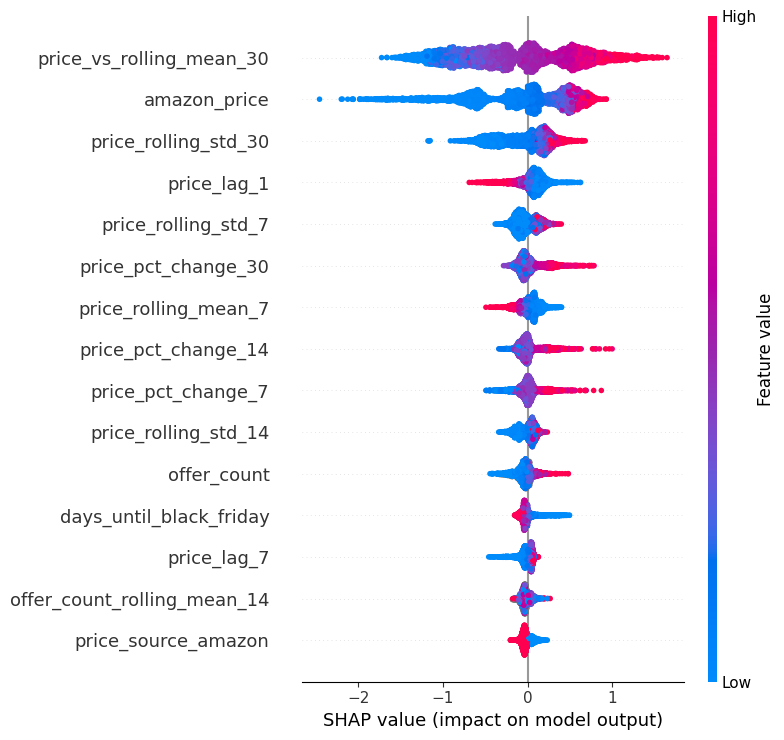

In [63]:
# Cell 34 - SHAP Explainability for the 14-Day Model

try:
    import shap

    horizon = 14
    label_col = f"label_drop_{horizon}d"

    modelling_df = df.dropna(subset=[label_col]).copy()
    modelling_df[FEATURE_COLS] = modelling_df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

    val_df = modelling_df[modelling_df["split"] == "validation"].copy()

    # Use a sample to keep the notebook lightweight
    shap_sample = val_df[FEATURE_COLS].sample(
        n=min(5000, len(val_df)),
        random_state=RANDOM_STATE
    )

    explainer = shap.TreeExplainer(trained_models[horizon])
    shap_values = explainer.shap_values(shap_sample)

    shap.summary_plot(
        shap_values,
        shap_sample,
        max_display=15,
        show=True
    )

except ImportError:
    print("SHAP is not installed. Install it with: pip install shap")

### SHAP Interpretation

The SHAP summary plot shows that the 14-day model is mainly driven by price-history features. The most influential feature is `price_vs_rolling_mean_30`, meaning the model strongly considers whether the current price is above or below its recent 30-day average.

Other important features include the current `amazon_price`, recent price volatility features such as `price_rolling_std_30` and `price_rolling_std_7`, and recent price-change features such as `price_pct_change_30`, `price_pct_change_14`, and `price_pct_change_7`.

This is consistent with the modelling objective. Products whose current price is high relative to recent history, or whose recent price behaviour suggests volatility, are more likely to receive higher predicted price-drop probabilities.

The SHAP analysis therefore supports that the model is using meaningful pricing signals rather than relying on unrelated or arbitrary features.

## Save Final V2.1 Artifacts

The final V2.1 artifacts are saved separately under `models/v2_1/`. These files do not overwrite the existing MVP model.

The saved outputs include the three trained XGBoost models, the shared feature list, model metadata, baseline results, threshold analysis, three-zone evaluation, and shopper backtest results.

In [64]:
# Cell X - Save Final V2.1 Model Artifacts and Evaluation Outputs

metadata = {
    "model_version": "v2_1_multihorizon",
    "horizons": HORIZONS,
    "label_definition": {
        "minimum_drop_percentage": MIN_DROP_PCT,
        "minimum_absolute_drop": MIN_DROP_ABSOLUTE,
        "description": (
            "Positive label means the selected modelling price drops by at least "
            "5% and at least $5 within the future horizon window."
        ),
    },
    "training_setup": {
        "model_family": "XGBoost",
        "class_weighting": "unweighted",
        "eval_metric": "auc",
        "early_stopping_rounds": 50,
        "n_estimators_limit": 2000,
        "note": (
            "The final setup follows the original MVP modelling style while extending "
            "the prediction task to 7-day, 14-day, and 30-day horizons."
        ),
    },
    "threshold_selection": {
        "classification_threshold_method": "validation_f1_maximisation",
        "classification_threshold_grid": "0.05 to 0.95 in 0.01 increments",
        "product_buy_now_threshold": BUY_NOW_THRESHOLD,
        "product_wait_threshold": WAIT_THRESHOLD,
        "note": (
            "F1-selected thresholds are used for binary model evaluation. "
            "The stricter product thresholds are used for user-facing BUY NOW, WAIT, and UNCERTAIN zones."
        ),
    },
    "feature_columns": FEATURE_COLS,
    "random_state": RANDOM_STATE,
    "xgboost_results": xgb_results_df.to_dict(orient="records"),
    "best_test_models_by_f1": best_by_f1_df.to_dict(orient="records"),
}

for horizon, model in trained_models.items():
    model_path = OUTPUT_DIR / f"xgb_price_drop_{horizon}d_model.joblib"
    joblib.dump(model, model_path)
    print(f"Saved model: {model_path}")

with open(OUTPUT_DIR / "feature_columns.json", "w") as f:
    json.dump(FEATURE_COLS, f, indent=2)

with open(OUTPUT_DIR / "model_metadata_multihorizon.json", "w") as f:
    json.dump(metadata, f, indent=2)

baseline_results_df.to_csv(OUTPUT_DIR / "baseline_results.csv", index=False)
xgb_results_df.to_csv(OUTPUT_DIR / "xgboost_multihorizon_results.csv", index=False)
model_comparison_df.to_csv(OUTPUT_DIR / "model_comparison_results.csv", index=False)
top_thresholds_df.to_csv(OUTPUT_DIR / "top_thresholds_by_horizon.csv", index=False)
selected_threshold_summary.to_csv(OUTPUT_DIR / "selected_threshold_summary.csv", index=False)
three_zone_df.to_csv(OUTPUT_DIR / "three_zone_evaluation.csv", index=False)
backtest_df.to_csv(OUTPUT_DIR / "shopper_backtest_results.csv", index=False)

print("Saved all V2.1 model artifacts and evaluation outputs.")

Saved model: /Users/hibaswaidan/Desktop/smart-buy-window-predictor/models/v2_1/xgb_price_drop_7d_model.joblib
Saved model: /Users/hibaswaidan/Desktop/smart-buy-window-predictor/models/v2_1/xgb_price_drop_14d_model.joblib
Saved model: /Users/hibaswaidan/Desktop/smart-buy-window-predictor/models/v2_1/xgb_price_drop_30d_model.joblib
Saved all V2.1 model artifacts and evaluation outputs.


In [65]:
# Cell X - Check Saved V2.1 Files

saved_files = sorted([path.name for path in OUTPUT_DIR.iterdir()])
saved_files

['baseline_results.csv',
 'feature_columns.json',
 'model_comparison_results.csv',
 'model_metadata_multihorizon.json',
 'selected_threshold_summary.csv',
 'shopper_backtest_results.csv',
 'three_zone_evaluation.csv',
 'top_thresholds_by_horizon.csv',
 'xgb_price_drop_14d_model.joblib',
 'xgb_price_drop_30d_model.joblib',
 'xgb_price_drop_7d_model.joblib',
 'xgboost_multihorizon_results.csv']

## Final Summary

This notebook developed and evaluated a V2.1 multi-horizon price-drop prediction system for the Smart Buy Window Predictor. Unlike the original MVP model, which predicted only a 14-day meaningful price drop, this version trains separate models for 7-day, 14-day, and 30-day prediction windows.

The modelling dataset was built from the cleaned V2 Keepa history, containing 1,951,779 product-day rows across 922 ASINs. For each product-day, three labels were created: `label_drop_7d`, `label_drop_14d`, and `label_drop_30d`. A positive label means that the selected modelling price drops by at least 5% and at least $5 within the relevant future window. The recreated 14-day label was validated against the original MVP target and achieved a 1.0 match rate, confirming that the new label-generation process is consistent with the original pipeline.

The same 45-feature V2 feature set was used across all horizons. These features include price lags, rolling price statistics, price-change features, sales-rank signals, offer-count signals, missingness indicators, price-source indicators, calendar/event features, and category features. A chronological split was used: training data before 2025, validation data from 2025, and test data from 2026.

Baseline models were evaluated before XGBoost, including a majority baseline, a rule-based baseline, and logistic regression. XGBoost achieved the best F1-score for all three horizons, showing that it adds predictive value beyond simpler approaches.

The final XGBoost test results were:

| Horizon | Threshold | ROC-AUC | PR-AUC | F1 | Precision | Recall | Accuracy |
|---|---:|---:|---:|---:|---:|---:|---:|
| 7 days | 0.25 | 0.8130 | 0.5210 | 0.5310 | 0.4513 | 0.6450 | 0.7821 |
| 14 days | 0.29 | 0.8182 | 0.6575 | 0.6374 | 0.5651 | 0.7310 | 0.7518 |
| 30 days | 0.33 | 0.8225 | 0.7770 | 0.7189 | 0.6535 | 0.7989 | 0.7343 |

The 30-day model achieved the strongest performance because longer prediction windows provide more opportunity for a meaningful price drop to occur. The 7-day model was the most difficult task because short-term drops are less frequent and harder to predict.

The notebook also evaluated a three-zone recommendation design using conservative product thresholds. A prediction is classified as BUY NOW when the probability is at most 0.25, WAIT when it is at least 0.65, and UNCERTAIN otherwise. This separates model evaluation from user-facing recommendation logic. The F1-selected threshold is useful for evaluating binary classification, while the stricter product thresholds are safer for the website because they avoid giving strong WAIT recommendations when confidence is only moderate.

The shopper backtest was updated to follow the final product recommendation logic. It evaluates only decisive BUY NOW or WAIT recommendations and treats intermediate cases as UNCERTAIN. Both optimistic and conservative waiting assumptions were tested. This makes the evaluation more realistic and highlights the tradeoff between potential savings and the risk of waiting too long.

SHAP explainability was added for the 14-day model. The SHAP summary showed that the model is mainly driven by meaningful pricing signals, especially the current price relative to the 30-day rolling mean, price volatility, and recent price-change features. This supports that the model is learning relevant price-history patterns rather than relying on arbitrary features.

Overall, the V2.1 multi-horizon approach is stronger than the original 14-day-only MVP because it provides real predictions for multiple waiting windows, supports a clearer BUY NOW / WAIT / UNCERTAIN recommendation design, and includes more complete evaluation through baselines, threshold analysis, three-zone evaluation, shopper backtesting, and SHAP explainability.

The V2.1 artifacts are saved separately under `models/v2_1/` and do not overwrite the current MVP model. This allows the existing deployment to remain stable while the multi-horizon system is integrated later as a controlled enhancement.